Train Path: /kaggle/input/datasets/chandanakuntala/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1
Validation Path: /kaggle/input/datasets/chandanakuntala/cropped-lisa-traffic-light-dataset/cropped_lisa_1/val_1
Found 32797 images belonging to 7 classes.
Found 3737 images belonging to 7 classes.
Classes: {'go': 0, 'goForward': 1, 'goLeft': 2, 'stop': 3, 'stopLeft': 4, 'warning': 5, 'warningLeft': 6}


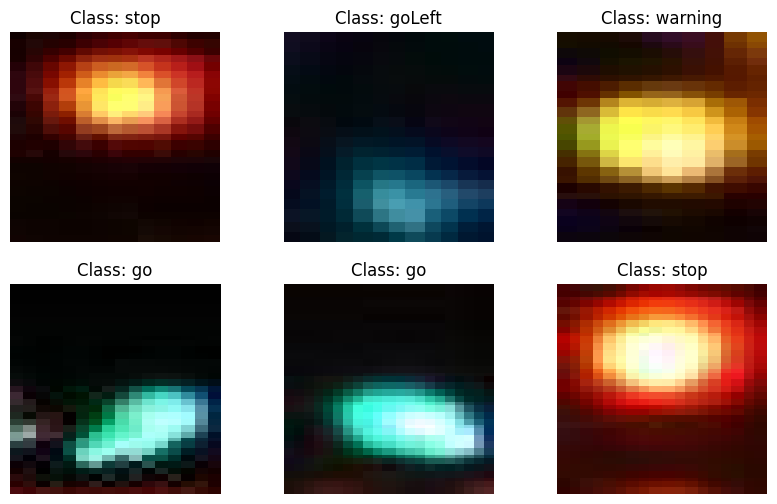

Epoch 1/2
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.8991 - loss: 0.3402 - val_accuracy: 0.9294 - val_loss: 0.2918
Epoch 2/2
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.9691 - loss: 0.0934 - val_accuracy: 0.9427 - val_loss: 0.1622
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9420 - loss: 0.1678
Final Accuracy: 0.9427348375320435
Model saved at /kaggle/working/


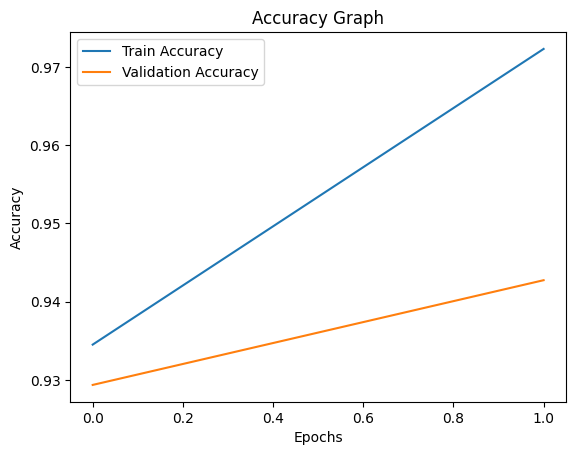

In [7]:
# =========================
# STEP 0: Setup
# =========================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import pickle

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# =========================
# STEP 1: Dataset Path
# =========================
path = "/kaggle/input/datasets/chandanakuntala/cropped-lisa-traffic-light-dataset/cropped_lisa_1"

train_dir = os.path.join(path, "train_1")
val_dir = os.path.join(path, "val_1")

print("Train Path:", train_dir)
print("Validation Path:", val_dir)

# =========================
# STEP 2: Data Preprocessing
# =========================
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)

print("Classes:", train_data.class_indices)

# =========================
# STEP 3: SHOW SAMPLE IMAGES (IMPORTANT)
# =========================
images, labels = next(train_data)

plt.figure(figsize=(10,6))

class_names = list(train_data.class_indices.keys())

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(f"Class: {class_names[np.argmax(labels[i])]}")
    plt.axis('off')

plt.show()

# =========================
# STEP 4: BUILD CNN MODEL
# =========================
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

# =========================
# STEP 5: COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# STEP 6: TRAIN
# =========================
history = model.fit(
    train_data,
    epochs=2,
    validation_data=val_data
)

# =========================
# STEP 7: EVALUATE
# =========================
loss, acc = model.evaluate(val_data)
print("Final Accuracy:", acc)

# =========================
# STEP 8: SAVE MODEL (.pkl)
# =========================
with open("/kaggle/working/cnn_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved at /kaggle/working/")

# =========================
# STEP 9: PLOT GRAPH
# =========================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()